<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/LateFusionBCNN_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [ ]:
# in a setup cell
!pip install blitz-bayesian-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.8 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1R0Rm_tQkPv4BMW6L3PT9j80xpPsVEffJ/REU ECG Analysis
 BCNN		        EchonextBigData
 CNN		        EchoNext_EchoData_5K.csv
'CNN Models ALL.gdoc'  'Project Summary.gdoc'
 ECG_metrics_1K.npy    'TripleCNN Model Overview (Pooling Methods).gdoc'
 ECG_waveforms_1K.npy


Using device: cuda
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles (Bayesian) ====
Sample 000 (DF Index: 477) | True: 1 | Pred: 1 | Confidence: 0.7764 | Uncertainty (Std): 0.0221
Sample 001 (DF Index: 837) | True: 1 | Pred: 1 | Confidence: 1.0000 | Uncertainty (Std): 0.0000
Sample 002 (DF Index: 302) | True: 1 | Pred: 1 | Confidence: 0.6997 | Uncertainty (Std): 0.0320
Sample 003 (DF Index: 405) | True: 0 | Pred: 0 | Confidence: 0.6556 | Uncertainty (Std): 0.0258
Sample 004 (DF Index: 333) | True: 1 | Pred: 1 | Confidence: 0.8002 | Uncertainty (Std): 0.0173
Sample 005 (DF Index: 332) | True: 1 | Pred: 1 | Confidence: 0.7287 | Uncertainty (Std): 0.0129
Sample 006 (DF Index: 886) | True: 0 | Pred: 0 | Confidence: 0.7391 | Uncertainty (Std): 0.0286
Sample 007 (DF Index: 730) | True: 0 | Pred: 0 | Confidence: 0.5750 | Uncertainty (Std): 0.0201
Sample 008 (DF Index: 775) | True: 0 | Pred: 1 | Confidence: 0.6034 | Uncertainty (Std): 0.0181
Sa

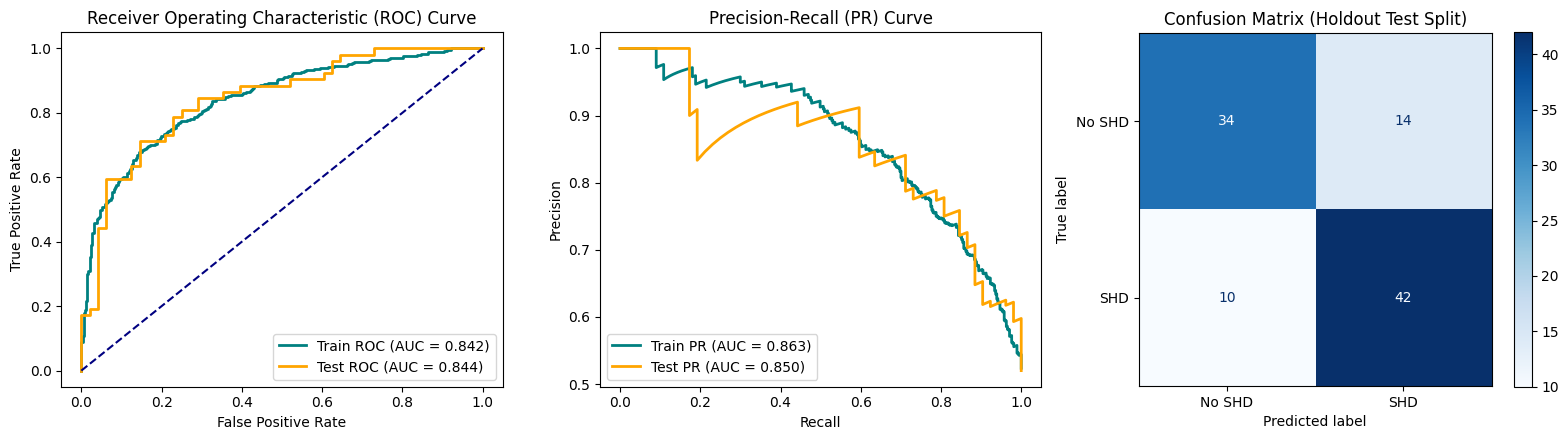

In [6]:
"""
evaluate_bayesian_late_fusion_classifier.py
────────────────────────────────────────────────────────────────────────────────
Loads ECG and demographic data, preprocesses features, trains a multimodal
Bayesian (BLiTZ-based) Late Fusion CNN + Demographic Neural Network, estimates
predictive posterior distributions, and evaluates comparative performance.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)
from blitz.modules import BayesianLinear, BayesianConv1d
from blitz.utils import variational_estimator

# ──────────────────────────────────────────────────────────────────────
# 1. GLOBAL CONFIGURATION & REPRODUCIBILITY
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected"
]
ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS

ECG_SAMPLING_RATE_HZ = 500
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# Bayesian priors scale-mixture settings
PRIOR_SIGMA_1 = 2.0
PRIOR_SIGMA_2 = 0.0025
PRIOR_PI = 1.0
POSTERIOR_RHO_INIT = -5.0

# ──────────────────────────────────────────────────────────────────────
# 2. SIGNAL PROCESSING & PREPROCESSING PIPELINES
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

def preprocess_demographics_pipeline(
    df: pd.DataFrame,
    scaler: StandardScaler = None,
    imputer: KNNImputer = None,
    knn_k: int = 3,
    fit: bool = True,
    known_feature_names: list = None
):
    df_working = df[ALL_DEMO_COLS].copy()

    cat_codes = df_working[CATEGORICAL_COLS].apply(
        lambda col: col.astype("category").cat.codes.replace(-1, np.nan)
    )
    cont_part = df_working[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    if imputer is None:
        imputer = KNNImputer(n_neighbors=knn_k)

    if fit:
        imputed = imputer.fit_transform(imputer_input)
    else:
        imputed = imputer.transform(imputer_input)

    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df_working.index)

    for col in CATEGORICAL_COLS:
        original_cats = df_working[col].astype("category").cat.categories
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = original_cats[codes_rounded].values

    ohe_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)

    if fit:
        current_feature_names = list(ohe_df.columns)
    else:
        if known_feature_names is None:
            raise ValueError("known_feature_names must be provided when fit=False")
        ohe_df = ohe_df.reindex(columns=known_feature_names, fill_value=0)
        current_feature_names = known_feature_names

    if scaler is None:
        scaler = StandardScaler()

    cont_indices = [current_feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)

    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, imputer, current_feature_names

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATASET INFRASTRUCTURE
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts, X_demo, y):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch across tensor targets."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. NEURAL NETWORK ARCHITECTURE (Bayesian Late Fusion BCNN)
# ──────────────────────────────────────────────────────────────────────
class BayesianDemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.fc1 = BayesianLinear(
            input_dim, 32,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )
        self.relu = nn.ReLU()
        self.fc2 = BayesianLinear(
            32, output_dim,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return x

@variational_estimator
class BayesianLateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        def bconv(in_c, out_c, k, p):
            return BayesianConv1d(
                in_c, out_c, kernel_size=k, padding=p,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        def blinear(in_f, out_f):
            return BayesianLinear(
                in_f, out_f,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        self.conv1 = bconv(in_channels, 16, 15, 7)
        self.pool1 = nn.AvgPool1d(kernel_size=10)   # 2500 -> 250

        self.conv2 = bconv(16, 32, 9, 4)
        self.pool2 = nn.AvgPool1d(kernel_size=10)   # 250 -> 25

        self.conv3 = bconv(32, 32, 5, 2)
        self.gap   = nn.AdaptiveAvgPool1d(1)        # 25 -> 1

        self.relu = nn.ReLU()

        self.demog_features = BayesianDemographicMLP(input_dim=demog_dim, output_dim=16)

        self.fc_out1 = blinear(32 + 16, 32)
        self.fc_out2 = blinear(32, num_classes)

    def forward(self, ts_input, demog_input):
        x = self.relu(self.conv1(ts_input))
        x = self.pool1(x)

        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.relu(self.conv3(x))
        x = self.gap(x)
        ts_emb = torch.flatten(x, start_dim=1)          # [B, 32]

        demog_emb = self.demog_features(demog_input)    # [B, 16]

        fused = torch.cat((ts_emb, demog_emb), dim=1)   # [B, 48]
        out = self.relu(self.fc_out1(fused))
        out = self.fc_out2(out)
        return out

# ──────────────────────────────────────────────────────────────────────
# 5. TRAINING ROUTINE
# ──────────────────────────────────────────────────────────────────────
def train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4, sample_nbr=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    n_train = len(train_loader.dataset)

    for epoch in range(epochs):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            # Add small channel noise as per training structure
            X_ts_b = X_ts_b + 0.05 * torch.randn_like(X_ts_b)

            optimizer.zero_grad()

            # Average NLL loss over variational draws
            nll = 0.0
            for _ in range(sample_nbr):
                logits = model(X_ts_b, X_demo_b)
                nll += criterion(logits, y_b)
            nll = nll / sample_nbr

            kl = model.nn_kl_divergence()
            loss = nll + kl / n_train

            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, X_demo_v, y_v in val_loader:
                X_ts_v, X_demo_v, y_v = X_ts_v.to(device), X_demo_v.to(device), y_v.to(device)

                probs_accum = 0.0
                for _ in range(sample_nbr):
                    logits_v = model(X_ts_v, X_demo_v)
                    probs_accum += torch.softmax(logits_v, dim=-1)
                probs_mean = probs_accum / sample_nbr

                val_loss += criterion(torch.log(probs_mean + 1e-8), y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        scheduler.step(val_loss / val_total)

# ──────────────────────────────────────────────────────────────────────
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader, mc_samples=30):
    """
    Stochastic MC Dropout equivalent for BCNN parameter variational inference.
    """
    model.eval()
    all_probs = []
    all_stds = []
    all_labels = []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)

            batch_probs = []
            for _ in range(mc_samples):
                logits = model(X_ts_b, X_demo_b)
                probs = torch.softmax(logits, dim=-1)
                batch_probs.append(probs.cpu().numpy())

            batch_probs = np.array(batch_probs) # [mc_samples, B, classes]
            mean_prob = np.mean(batch_probs, axis=0)
            std_prob = np.std(batch_probs[:, :, 1], axis=0)

            eps = 1e-8
            log_mean_prob = torch.log(torch.tensor(mean_prob) + eps).to(device)
            all_nll += criterion(log_mean_prob, y_b.to(device)).item()

            all_probs.extend(mean_prob[:, 1])
            all_stds.extend(std_prob)
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_stds), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader):
    train_probs, _, train_labels, train_nll = get_predictions_and_labels(model, train_loader, mc_samples=30)
    test_probs, _, test_labels, test_nll = get_predictions_and_labels(model, test_loader, mc_samples=30)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 7. EXECUTION PIPELINE EXECUTION
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    ecg_path = 'ECG_waveforms_1K.npy'
    echo_path = 'EchoNext_EchoData_5K.csv'

    X_raw = np.load(ecg_path)[:1000]
    echo_df = pd.read_csv(echo_path).iloc[:1000].reset_index(drop=True)
    y_raw = echo_df['shd_moderate_or_greater_flag'].to_numpy()

    # ── STEP B: WAVEFORM PRE-FILTERING ──────────────────────────────
    X_filtered = np.array([bandpass_filter_ecg(x, fs=250) for x in X_raw])
    X_ts = np.swapaxes(X_filtered, 1, 2)
    demo_df = echo_df[ALL_DEMO_COLS].copy()

    # ── STEP C: DATASET PARTITIONING ──
    total_indices = np.arange(len(y_raw))

    rem_indices, test_indices = train_test_split(
        total_indices, test_size=0.10, random_state=RANDOM_SEED, stratify=y_raw
    )
    train_indices, val_indices = train_test_split(
        rem_indices, test_size=0.20, random_state=RANDOM_SEED, stratify=y_raw[rem_indices]
    )

    # ── STEP D: TRANSFORM DEMOGRAPHICS ──
    train_val_df_raw = demo_df.iloc[rem_indices]
    _, fitted_scaler, fitted_imputer, fitted_feature_names = preprocess_demographics_pipeline(
        train_val_df_raw, scaler=None, imputer=None, fit=True
    )

    demo_train, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[train_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )
    demo_val, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[val_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )
    demo_test, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[test_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )

    train_loader = DataLoader(FusedDataset(X_ts[train_indices], demo_train, y_raw[train_indices]), batch_size=32, shuffle=True)
    val_loader   = DataLoader(FusedDataset(X_ts[val_indices],   demo_val,   y_raw[val_indices]),   batch_size=128, shuffle=False)
    test_loader  = DataLoader(FusedDataset(X_ts[test_indices],  demo_test,  y_raw[test_indices]),  batch_size=128, shuffle=False)

    # ── STEP E: INITIALIZE & TRAIN THE MODEL ──────────────────────────
    model = BayesianLateFusionHeartDiseaseModel(
        sequence_length=X_ts.shape[2], in_channels=X_ts.shape[1],
        demog_dim=demo_train.shape[1], num_classes=2
    )

    print("Training model...")
    train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4, sample_nbr=3)

    torch.manual_seed(RANDOM_SEED)

    # ── STEP F: PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ─────────────
    print("\n===== Individual Test Sample Inference Profiles (Bayesian) ====")
    test_probs, test_stds, test_labels, _ = get_predictions_and_labels(model, test_loader, mc_samples=30)

    for idx in range(len(test_probs)):
        true_val = test_labels[idx]
        pred_val = int(test_probs[idx] >= 0.5)
        confidence = test_probs[idx] if pred_val == 1 else (1.0 - test_probs[idx])
        uncertainty = test_stds[idx]  # Epistemic variation across samples
        global_df_idx = test_indices[idx]

        print(f"Sample {idx:03d} (DF Index: {global_df_idx:03d}) | "
              f"True: {true_val} | Pred: {pred_val} | "
              f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")

    # ── STEP G: SYSTEM METRICS ANALYSIS VISUALIZATIONS ────────────────
    generate_and_display_comparative_metrics(model, train_loader, test_loader)